V2 WITH XGBOOST AND DECISION TREE:

XGBoost is available
Available columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets']...
Combined dataset size: (50000, 79)
Class distribution:
Label
BENIGN           49086
DoS slowloris      912
Name: count, dtype: int64

Preprocessing data...
Train set: (39949, 78), Test set: (9988, 78)
Number of classes: 2

GRID SEARCH TO OPTIMIZE BASELINE MODELS

1. Grid Search - Random Forest...
Fitting 2 folds for each of 8 candidates, totalling 16 fits
Best RF parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 0.9997
Time: 150.33s

2. Grid Search - Decision Tree...
Fitting 2 folds for each of 72 candidates, totalling 144 fits
Best DT parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV score: 0.9996
Time: 77.31s

3. Grid Search - Gradient Boosting...
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Best GB parameters: {'lea

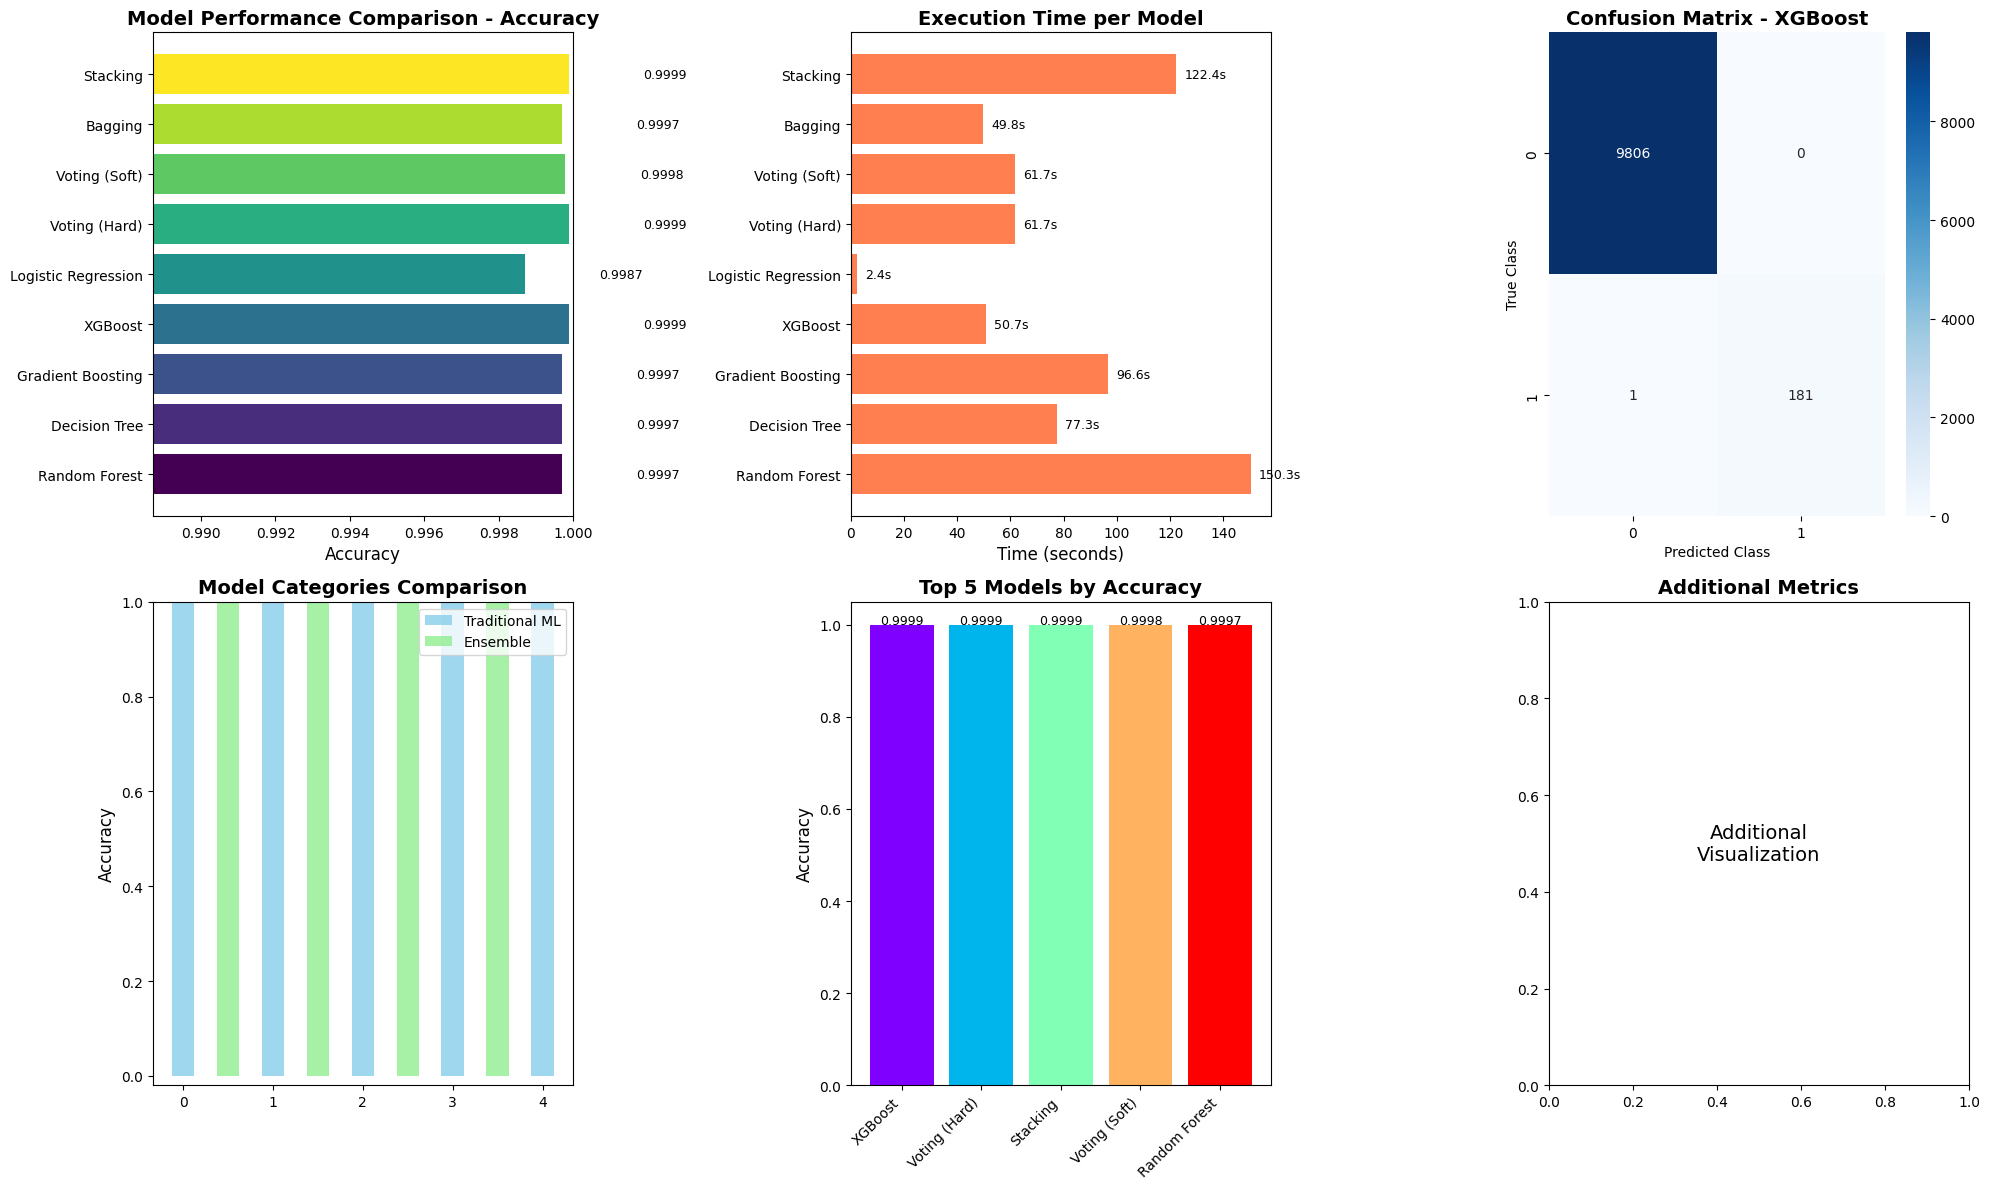

Graph saved: detailed_metrics_extended.png


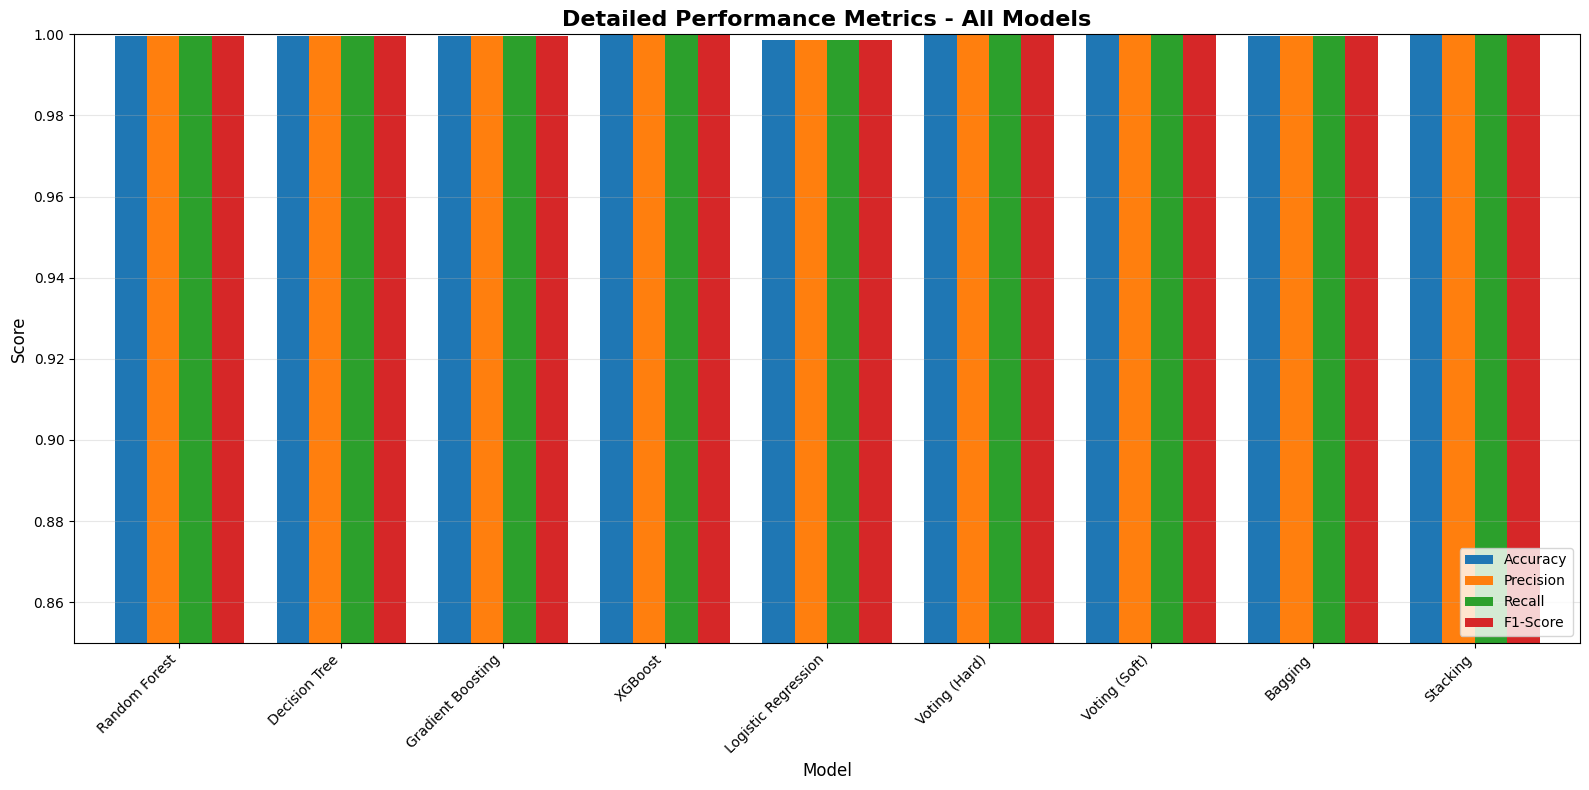


FINAL SUMMARY

Results Table:
              Model  Accuracy  Precision   Recall  F1-Score
            XGBoost  0.999900   0.999900 0.999900  0.999900
           Stacking  0.999900   0.999900 0.999900  0.999900
      Voting (Hard)  0.999900   0.999900 0.999900  0.999900
      Voting (Soft)  0.999800   0.999800 0.999800  0.999800
      Random Forest  0.999700   0.999699 0.999700  0.999699
      Decision Tree  0.999700   0.999705 0.999700  0.999701
  Gradient Boosting  0.999700   0.999699 0.999700  0.999699
            Bagging  0.999700   0.999699 0.999700  0.999699
Logistic Regression  0.998698   0.998690 0.998698  0.998693

Best Model: XGBoost
   Accuracy: 0.9999
   Time: 50.65s

Model Category Summary:
   Traditional ML models: 5
   Deep Learning models: 0
   Ensemble models: 4

Pipeline completed successfully!
Total execution time: 672.95s

Results saved to: model_results_extended.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, BaggingClassifier, StackingClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import time
import warnings
warnings.filterwarnings('ignore')

# Try to import XGBoost and TensorFlow/Keras
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
    print("XGBoost is available")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed. Install with: pip install xgboost")


# ==================== DATA LOADING ====================

monday = pd.read_csv(r"Monday-WorkingHours.pcap_ISCX.csv")
wednesday = pd.read_csv(r"Wednesday-workingHours.pcap_ISCX.csv")

# Combine datasets
data = pd.concat([monday, wednesday], ignore_index=True)

# Clean column names (remove leading/trailing spaces)
data.columns = data.columns.str.strip()

# Check available columns
print(f"Available columns: {data.columns.tolist()[:5]}...")

# SAMPLE DATA FOR FASTER EXECUTION (remove this line for full dataset)
data = data.sample(n=min(50000, len(data)), random_state=42)

print(f"Combined dataset size: {data.shape}")
print(f"Class distribution:\n{data['Label'].value_counts()}")

# ==================== PREPROCESSING ====================
print("\nPreprocessing data...")

# Clean data
data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna()

# Encode labels
le = LabelEncoder()
data['Label_encoded'] = le.fit_transform(data['Label'])
num_classes = len(le.classes_)

# Separate features and target
X = data.drop(['Label', 'Label_encoded'], axis=1)
y = data['Label_encoded']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train set: {X_train_scaled.shape}, Test set: {X_test_scaled.shape}")
print(f"Number of classes: {num_classes}")

# ==================== GRID SEARCH FOR BASELINE MODELS ====================
print("\n" + "="*60)
print("GRID SEARCH TO OPTIMIZE BASELINE MODELS")
print("="*60)

# Dictionary to store results
results = {}
best_models = {}

# 1. Random Forest
print("\n1. Grid Search - Random Forest...")
start = time.time()
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [20, None],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params,
                       cv=2, n_jobs=-1, verbose=1, scoring='accuracy')
rf_grid.fit(X_train_scaled, y_train)
rf_time = time.time() - start

print(f"Best RF parameters: {rf_grid.best_params_}")
print(f"Best CV score: {rf_grid.best_score_:.4f}")
print(f"Time: {rf_time:.2f}s")

best_models['Random Forest'] = rf_grid.best_estimator_
y_pred_rf = rf_grid.predict(X_test_scaled)
results['Random Forest'] = {
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'best_params': rf_grid.best_params_,
    'cv_score': rf_grid.best_score_,
    'time': rf_time,
    'predictions': y_pred_rf
}

# 2. Decision Tree
print("\n2. Grid Search - Decision Tree...")
start = time.time()
dt_params = {
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params,
                       cv=2, n_jobs=-1, verbose=1, scoring='accuracy')
dt_grid.fit(X_train_scaled, y_train)
dt_time = time.time() - start

print(f"Best DT parameters: {dt_grid.best_params_}")
print(f"Best CV score: {dt_grid.best_score_:.4f}")
print(f"Time: {dt_time:.2f}s")

best_models['Decision Tree'] = dt_grid.best_estimator_
y_pred_dt = dt_grid.predict(X_test_scaled)
results['Decision Tree'] = {
    'accuracy': accuracy_score(y_test, y_pred_dt),
    'best_params': dt_grid.best_params_,
    'cv_score': dt_grid.best_score_,
    'time': dt_time,
    'predictions': y_pred_dt
}

# 3. Gradient Boosting
print("\n3. Grid Search - Gradient Boosting...")
start = time.time()
gb_params = {
    'n_estimators': [50],
    'learning_rate': [0.1],
    'max_depth': [5]
}
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_params,
                       cv=2, n_jobs=-1, verbose=1, scoring='accuracy')
gb_grid.fit(X_train_scaled, y_train)
gb_time = time.time() - start

print(f"Best GB parameters: {gb_grid.best_params_}")
print(f"Best CV score: {gb_grid.best_score_:.4f}")
print(f"Time: {gb_time:.2f}s")

best_models['Gradient Boosting'] = gb_grid.best_estimator_
y_pred_gb = gb_grid.predict(X_test_scaled)
results['Gradient Boosting'] = {
    'accuracy': accuracy_score(y_test, y_pred_gb),
    'best_params': gb_grid.best_params_,
    'cv_score': gb_grid.best_score_,
    'time': gb_time,
    'predictions': y_pred_gb
}

# 4. XGBoost
if XGBOOST_AVAILABLE:
    print("\n4. Grid Search - XGBoost...")
    start = time.time()
    xgb_params = {
        'n_estimators': [100, 200],
        'max_depth': [5, 7, 10],
        'learning_rate': [0.1, 0.2],
        'subsample': [0.8, 1.0]
    }
    xgb_grid = GridSearchCV(xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
                           xgb_params, cv=2, n_jobs=-1, verbose=1, scoring='accuracy')
    xgb_grid.fit(X_train_scaled, y_train)
    xgb_time = time.time() - start

    print(f"Best XGB parameters: {xgb_grid.best_params_}")
    print(f"Best CV score: {xgb_grid.best_score_:.4f}")
    print(f"Time: {xgb_time:.2f}s")

    best_models['XGBoost'] = xgb_grid.best_estimator_
    y_pred_xgb = xgb_grid.predict(X_test_scaled)
    results['XGBoost'] = {
        'accuracy': accuracy_score(y_test, y_pred_xgb),
        'best_params': xgb_grid.best_params_,
        'cv_score': xgb_grid.best_score_,
        'time': xgb_time,
        'predictions': y_pred_xgb
    }
else:
    print("\n4. XGBoost - SKIPPED (not installed)")

# 5. Logistic Regression
print("\n5. Grid Search - Logistic Regression...")
start = time.time()
lr_params = {
    'C': [0.1, 1, 10],
    'penalty': ['l2'],
    'max_iter': [1000]
}
lr_grid = GridSearchCV(LogisticRegression(random_state=42, solver='lbfgs'), lr_params,
                       cv=2, n_jobs=-1, verbose=1, scoring='accuracy')
lr_grid.fit(X_train_scaled, y_train)
lr_time = time.time() - start

print(f"Best LR parameters: {lr_grid.best_params_}")
print(f"Best CV score: {lr_grid.best_score_:.4f}")
print(f"Time: {lr_time:.2f}s")

best_models['Logistic Regression'] = lr_grid.best_estimator_
y_pred_lr = lr_grid.predict(X_test_scaled)
results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'best_params': lr_grid.best_params_,
    'cv_score': lr_grid.best_score_,
    'time': lr_time,
    'predictions': y_pred_lr
}



# ==================== ENSEMBLE MODELS ====================
print("\n" + "="*60)
print("ENSEMBLE MODELS")
print("="*60)

# 1. Voting Classifier
print("\n1. Voting Classifier (Hard & Soft)...")
start = time.time()

voting_estimators = [
    ('rf', best_models['Random Forest']),
    ('dt', best_models['Decision Tree']),
    ('gb', best_models['Gradient Boosting'])
]

if XGBOOST_AVAILABLE:
    voting_estimators.append(('xgb', best_models['XGBoost']))

voting_hard = VotingClassifier(estimators=voting_estimators, voting='hard', n_jobs=-1)
voting_hard.fit(X_train_scaled, y_train)
y_pred_voting_hard = voting_hard.predict(X_test_scaled)

voting_soft = VotingClassifier(estimators=voting_estimators, voting='soft', n_jobs=-1)
voting_soft.fit(X_train_scaled, y_train)
y_pred_voting_soft = voting_soft.predict(X_test_scaled)

voting_time = time.time() - start

results['Voting (Hard)'] = {
    'accuracy': accuracy_score(y_test, y_pred_voting_hard),
    'time': voting_time/2,
    'predictions': y_pred_voting_hard
}
results['Voting (Soft)'] = {
    'accuracy': accuracy_score(y_test, y_pred_voting_soft),
    'time': voting_time/2,
    'predictions': y_pred_voting_soft
}

print(f"Voting Hard Accuracy: {results['Voting (Hard)']['accuracy']:.4f}")
print(f"Voting Soft Accuracy: {results['Voting (Soft)']['accuracy']:.4f}")

# 2. Bagging Classifier
print("\n2. Bagging Classifier...")
start = time.time()

bagging = BaggingClassifier(
    estimator=best_models['Random Forest'],
    n_estimators=5,
    random_state=42,
    n_jobs=-1
)
bagging.fit(X_train_scaled, y_train)
y_pred_bagging = bagging.predict(X_test_scaled)
bagging_time = time.time() - start

results['Bagging'] = {
    'accuracy': accuracy_score(y_test, y_pred_bagging),
    'time': bagging_time,
    'predictions': y_pred_bagging
}

print(f"Bagging Accuracy: {results['Bagging']['accuracy']:.4f}")

# 3. Stacking Classifier
print("\n3. Stacking Classifier...")
start = time.time()

stacking_estimators = [
    ('rf', best_models['Random Forest']),
    ('dt', best_models['Decision Tree']),
    ('gb', best_models['Gradient Boosting'])
]

if XGBOOST_AVAILABLE:
    stacking_estimators.append(('xgb', best_models['XGBoost']))

stacking = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=2,
    n_jobs=-1
)
stacking.fit(X_train_scaled, y_train)
y_pred_stacking = stacking.predict(X_test_scaled)
stacking_time = time.time() - start

results['Stacking'] = {
    'accuracy': accuracy_score(y_test, y_pred_stacking),
    'time': stacking_time,
    'predictions': y_pred_stacking
}

print(f"Stacking Accuracy: {results['Stacking']['accuracy']:.4f}")

# ==================== VISUALIZATIONS ====================
print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

# 1. Model Performance Comparison
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Subplot 1: Accuracy Comparison
model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]

axes[0, 0].barh(model_names, accuracies, color=plt.cm.viridis(np.linspace(0, 1, len(model_names))))
axes[0, 0].set_xlabel('Accuracy', fontsize=12)
axes[0, 0].set_title('Model Performance Comparison - Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].set_xlim([min(accuracies) - 0.01, 1.0])
for i, v in enumerate(accuracies):
    axes[0, 0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

# Subplot 2: Execution Time
times = [results[m]['time'] for m in model_names]
axes[0, 1].barh(model_names, times, color='coral')
axes[0, 1].set_xlabel('Time (seconds)', fontsize=12)
axes[0, 1].set_title('Execution Time per Model', fontsize=14, fontweight='bold')
for i, v in enumerate(times):
    axes[0, 1].text(v + max(times)*0.02, i, f'{v:.1f}s', va='center', fontsize=9)

# Subplot 3: Confusion Matrix for Best Model
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
cm = confusion_matrix(y_test, results[best_model_name]['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 2])
axes[0, 2].set_title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
axes[0, 2].set_ylabel('True Class')
axes[0, 2].set_xlabel('Predicted Class')

# Subplot 4: Traditional ML vs Deep Learning vs Ensemble
traditional_models = ['Random Forest', 'Decision Tree', 'Gradient Boosting', 'Logistic Regression']
if XGBOOST_AVAILABLE:
    traditional_models.append('XGBoost')

deep_models = []
ensemble_models = ['Voting (Hard)', 'Voting (Soft)', 'Bagging', 'Stacking']

trad_acc = [results[m]['accuracy'] for m in traditional_models if m in results]
deep_acc = [results[m]['accuracy'] for m in deep_models if m in results]
ens_acc = [results[m]['accuracy'] for m in ensemble_models if m in results]

x_pos = 0
bar_width = 0.25
colors_list = ['skyblue', 'lightcoral', 'lightgreen']

for idx, (acc_list, label, color) in enumerate([(trad_acc, 'Traditional ML', colors_list[0]),
                                                  (deep_acc, 'Deep Learning', colors_list[1]),
                                                  (ens_acc, 'Ensemble', colors_list[2])]):
    if acc_list:
        x_positions = np.arange(len(acc_list)) + idx * bar_width
        axes[1, 0].bar(x_positions, acc_list, bar_width, label=label, color=color, alpha=0.8)

axes[1, 0].set_ylabel('Accuracy', fontsize=12)
axes[1, 0].set_title('Model Categories Comparison', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].set_ylim([min(min(trad_acc, default=0), min(deep_acc, default=0), min(ens_acc, default=0)) - 0.02, 1.0])

# Subplot 5: Top 5 Models
top5_models = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)[:5]
top5_names = [m[0] for m in top5_models]
top5_acc = [m[1]['accuracy'] for m in top5_models]

axes[1, 1].bar(range(len(top5_names)), top5_acc, color=plt.cm.rainbow(np.linspace(0, 1, len(top5_names))))
axes[1, 1].set_xticks(range(len(top5_names)))
axes[1, 1].set_xticklabels(top5_names, rotation=45, ha='right', fontsize=10)
axes[1, 1].set_ylabel('Accuracy', fontsize=12)
axes[1, 1].set_title('Top 5 Models by Accuracy', fontsize=14, fontweight='bold')
for i, v in enumerate(top5_acc):
    axes[1, 1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=9)

# Subplot 6: Placeholder
axes[1, 2].text(0.5, 0.5, 'Additional\nVisualization',
                ha='center', va='center', fontsize=14, transform=axes[1, 2].transAxes)
axes[1, 2].set_title('Additional Metrics', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison_extended.png', dpi=300, bbox_inches='tight')
print("Graph saved: model_comparison_extended.png")
plt.show()

# 2. Detailed Metrics Report
fig, ax = plt.subplots(figsize=(16, 8))

metrics_data = []
for model_name in results.keys():
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, results[model_name]['predictions'], average='weighted'
    )
    metrics_data.append([model_name, results[model_name]['accuracy'], precision, recall, f1])

metrics_df = pd.DataFrame(metrics_data, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
metrics_df_plot = metrics_df.set_index('Model')

metrics_df_plot.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Detailed Performance Metrics - All Models', fontsize=16, fontweight='bold')
ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.legend(loc='lower right')
ax.set_ylim([0.85, 1.0])
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('detailed_metrics_extended.png', dpi=300, bbox_inches='tight')
print("Graph saved: detailed_metrics_extended.png")
plt.show()

# ==================== FINAL SUMMARY ====================
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

print("\nResults Table:")
metrics_df_sorted = metrics_df.sort_values('Accuracy', ascending=False)
print(metrics_df_sorted.to_string(index=False))

best_model_name = max(results, key=lambda x: results[x]['accuracy'])
print(f"\nBest Model: {best_model_name}")
print(f"   Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"   Time: {results[best_model_name]['time']:.2f}s")

print("\nModel Category Summary:")
print(f"   Traditional ML models: {len([m for m in traditional_models if m in results])}")
print(f"   Deep Learning models: {len(deep_models)}")
print(f"   Ensemble models: {len([m for m in ensemble_models if m in results])}")

print("\nPipeline completed successfully!")
print(f"Total execution time: {sum([r['time'] for r in results.values()]):.2f}s")

# Save results to CSV
metrics_df_sorted.to_csv('model_results_extended.csv', index=False)
print("\nResults saved to: model_results_extended.csv")

### Model Export for Deployment
The Stacking Classifier is serialized for the Network Security Officer component.
Since this model relies on scaled data, we must export both the model and the scaler used during training.

In [2]:
import joblib

print("--- FINAL EXPORT: NETWORK LAYER ---")

# 1. Save the Stacking Model
try:
    joblib.dump(stacking, 'model_network.pkl')
    print("Network Model saved (model_network.pkl)")
except NameError:
    print("ERROR: Variable 'stacking' not found.")

# 2. Save the Scaler (Crucial for this model)
try:
    joblib.dump(scaler, 'scaler_network.pkl')
    print("Network Scaler saved (scaler_network.pkl)")
except NameError:
    print("ERROR: Variable 'scaler' not found.")

--- FINAL EXPORT: NETWORK LAYER ---
Network Model saved (model_network.pkl)
Network Scaler saved (scaler_network.pkl)
